# DEQ-PC Debugging Notebook

Comprehensive analysis of Deep Equilibrium Predictive Coding model behavior.

In [1]:
import io
from contextlib import redirect_stderr, redirect_stdout
from collections import defaultdict

import jax
import jax.numpy as jnp
import jax.tree_util as jtu
import numpy as np
import optax
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import pcx as px
import pcx.functional as pxf
import pcx.nn as pxnn
import pcx.predictive_coding as pxc
import pcx.utils as pxu

px.RKG.seed(0)

# Plotting style
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

/home/tommaso.salvatori/miniconda3/envs/pcx/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Model Definition

Same architecture as original, unchanged.

In [2]:
class GroupNorm(px.Module):
    """Channel-first group normalisation with learnable affine."""
    def __init__(self, num_groups: int, num_channels: int, eps: float = 1e-5):
        super().__init__()
        self.num_groups = px.static(num_groups)
        self.eps = px.static(eps)
        self.weight = pxnn.LayerParam(jnp.ones(num_channels))
        self.bias = pxnn.LayerParam(jnp.zeros(num_channels))

    def __call__(self, x: jax.Array) -> jax.Array:
        C = x.shape[0]
        G = self.num_groups.get()
        g = x.reshape(G, C // G, *x.shape[1:])
        axes = tuple(range(1, g.ndim))
        mean = jnp.mean(g, axis=axes, keepdims=True)
        var = jnp.var(g, axis=axes, keepdims=True)
        g = (g - mean) / jnp.sqrt(var + self.eps.get())
        g = g.reshape(x.shape)
        s = (C,) + (1,) * (x.ndim - 1)
        return g * self.weight.get().reshape(s) + self.bias.get().reshape(s)


class ResNetLayer(px.Module):
    """f(z, x) = norm3(relu(z + norm2(x + conv2(norm1(relu(conv1(z))))))))"""
    def __init__(self, n_ch: int, n_inner: int, ks: int = 3, ng: int = 8):
        super().__init__()
        p = ks // 2
        self.conv1 = pxnn.Conv2d(n_ch, n_inner, ks, padding=(p, p), use_bias=False)
        self.conv2 = pxnn.Conv2d(n_inner, n_ch, ks, padding=(p, p), use_bias=False)
        self.norm1 = GroupNorm(ng, n_inner)
        self.norm2 = GroupNorm(ng, n_ch)
        self.norm3 = GroupNorm(ng, n_ch)
        for mod in (self.conv1, self.conv2):
            for leaf in jtu.tree_leaves(mod, is_leaf=lambda x: isinstance(x, pxnn.LayerParam)):
                if isinstance(leaf, pxnn.LayerParam):
                    leaf.set(jax.random.normal(px.RKG(), leaf.shape) * 0.01)

    def __call__(self, z: jax.Array, x: jax.Array) -> jax.Array:
        y = self.norm1(jax.nn.relu(self.conv1(z)))
        return self.norm3(jax.nn.relu(z + self.norm2(x + self.conv2(y))))


def nudged_ce_energy(nudging: float):
    def energy_fn(vode, rkg=px.RKG):
        return nudging * (-(vode.get("h") * jax.nn.log_softmax(vode.get("u"))))
    return energy_fn


class DEQPCModel(pxc.EnergyModule):
    def __init__(self, n_channels: int = 48, n_inner: int = 64, n_classes: int = 10, nudging: float = 0.1):
        super().__init__()
        self.n_classes = px.static(n_classes)
        self.n_channels = px.static(n_channels)
        self.nudging = px.static(nudging)

        self.input_conv = pxnn.Conv2d(3, n_channels, 3, padding=(1, 1), use_bias=True)
        self.gn_in = GroupNorm(8, n_channels)
        self.f = ResNetLayer(n_channels, n_inner)
        self.gn_out = GroupNorm(8, n_channels)
        self.pool = pxnn.AvgPool2d(kernel_size=8, stride=8)
        self.linear = pxnn.Linear(n_channels * 4 * 4, n_classes)

        self.vode_z = pxc.Vode()
        self.vode_out = pxc.Vode(nudged_ce_energy(nudging))
        self.vode_out.h.frozen = True

        self.x_inj_cache = pxc.VodeParam()
        self.x_inj_cache.frozen = True

    def embed(self, x: jax.Array) -> jax.Array:
        x_inj = self.gn_in(self.input_conv(x))
        self.x_inj_cache.set(x_inj)
        return x_inj

    def __call__(self, y: jax.Array | None = None) -> jax.Array:
        x_inj = self.x_inj_cache.get()
        z = self.vode_z.get("h")
        self.vode_z(self.f(z, x_inj))
        z_out = self.pool(self.gn_out(z)).flatten()
        logits = self.linear(z_out)
        self.vode_out(logits)
        if y is not None:
            self.vode_out.set("h", y)
        return logits

    def forward_full(self, x: jax.Array, y: jax.Array | None = None) -> jax.Array:
        self.embed(x)
        return self(y)

## Instrumented Inference Loop

Modified to track energy components, gradients, and residuals at each step.

In [3]:
# Original fast inference (no tracking, used in jitted functions)
def _run_inference_loop(T, z_h, x_inj, label_h, h_opt, model):
    """Fast inference without tracking - used inside jitted training."""
    h_opt_state = h_opt.init(z_h)
    nudging = model.nudging.get()
    
    @jax.checkpoint
    def per_sample_energy(z, x_i, lab):
        u_z = model.f(z, x_i)
        diff = z - u_z
        e_z = (0.5 * diff * diff).sum()
        
        z_out = model.pool(model.gn_out(z)).flatten()
        logits = model.linear(z_out)
        e_out = (nudging * (-(lab * jax.nn.log_softmax(logits)))).sum()
        
        return e_z + e_out
    
    per_sample_grad = jax.vmap(jax.grad(per_sample_energy))
    
    def body(_, carry):
        z_h, opt_state = carry
        grad_z = per_sample_grad(z_h, x_inj, label_h)
        updates, opt_state = h_opt.update(grad_z, opt_state, z_h)
        z_h = optax.apply_updates(z_h, updates)
        return z_h, opt_state
    
    z_h, _ = jax.lax.fori_loop(0, T, body, (z_h, h_opt_state))
    return z_h


# Diagnostic inference with detailed tracking (NOT jitted)
def run_inference_with_tracking(T, z_h, x_inj, label_h, h_opt, model):
    """Slower inference that tracks all diagnostics - NOT used in jitted context."""
    h_opt_state = h_opt.init(z_h)
    nudging = model.nudging.get()
    
    # Storage for tracking (as lists)
    energies_se = []
    energies_ce = []
    grad_norms = []
    residuals = []
    z_stats = []
    
    @jax.checkpoint
    def per_sample_energy_with_components(z, x_i, lab):
        u_z = model.f(z, x_i)
        diff = z - u_z
        e_z = (0.5 * diff * diff).sum()
        
        z_out = model.pool(model.gn_out(z)).flatten()
        logits = model.linear(z_out)
        e_out = (nudging * (-(lab * jax.nn.log_softmax(logits)))).sum()
        
        return e_z + e_out, (e_z, e_out, u_z)
    
    per_sample_grad = jax.vmap(jax.grad(per_sample_energy_with_components, has_aux=True))
    
    z_prev = z_h
    for t in range(T):
        grad_z, (e_se_batch, e_ce_batch, u_z_batch) = per_sample_grad(z_h, x_inj, label_h)
        
        # Track metrics - convert to numpy immediately
        energies_se.append(np.array(e_se_batch.mean()))
        energies_ce.append(np.array(e_ce_batch.mean()))
        grad_norms.append(np.array(jnp.linalg.norm(grad_z.reshape(grad_z.shape[0], -1), axis=1).mean()))
        residuals.append(np.array(jnp.linalg.norm((z_h - z_prev).reshape(z_h.shape[0], -1), axis=1).mean()))
        z_stats.append({
            'mean': float(z_h.mean()),
            'std': float(z_h.std()),
            'min': float(z_h.min()),
            'max': float(z_h.max())
        })
        
        # Update
        updates, h_opt_state = h_opt.update(grad_z, h_opt_state, z_h)
        z_prev = z_h
        z_h = optax.apply_updates(z_h, updates)
    
    # Compute final fixed point residual
    _, (_, _, u_z_final) = per_sample_grad(z_h, x_inj, label_h)
    
    metrics = {
        'energies_se': np.array(energies_se),
        'energies_ce': np.array(energies_ce),
        'grad_norms': np.array(grad_norms),
        'residuals': np.array(residuals),
        'z_stats': z_stats,
        'final_fixed_point_residual': float(jnp.linalg.norm((z_h - u_z_final).reshape(z_h.shape[0], -1), axis=1).mean())
    }
    
    return z_h, metrics

## PCX Functional Wrappers

In [4]:
_V = pxu.M(pxc.VodeParam | pxc.VodeParam.Cache).to((None, 0))

@pxf.vmap(_V, in_axes=(0, 0), out_axes=0)
def init_train(x, y, *, model: DEQPCModel):
    x_inj = model.embed(x)
    model.vode_z.h.set(jnp.zeros_like(x_inj))
    return model(y)

@pxf.vmap(_V, in_axes=(0,), out_axes=0)
def init_eval(x, *, model: DEQPCModel):
    x_inj = model.embed(x)
    model.vode_z.h.set(jnp.zeros_like(x_inj))
    model.vode_out.h.set(jnp.zeros(model.n_classes.get()))
    return model()

@pxf.vmap(_V, in_axes=(0,), out_axes=None, axis_name="batch")
def energy_weight(x, *, model: DEQPCModel):
    model.forward_full(x)
    return jax.lax.psum(model.energy(), "batch")

@pxf.vmap(_V, in_axes=(), out_axes=0)
def predict_cached(*, model: DEQPCModel):
    return model()

_w_mask = pxu.M(pxnn.LayerParam).to([False, True])

## Training Functions with Diagnostics

In [5]:
# Fast jitted training (no tracking)
@pxf.jit(static_argnums=0)
def train_on_batch(T: int, x: jax.Array, y: jax.Array, *, model: DEQPCModel, optim_w: pxu.Optim, optim_h: pxu.Optim):
    model.train()
    
    with pxu.step(model, clear_params=pxc.VodeParam.Cache):
        init_train(x, y, model=model)
    
    h_opt = optim_h.optax_opt_fn()
    z_h = _run_inference_loop(
        T, model.vode_z.h.get(), model.x_inj_cache.get(), model.vode_out.h.get(), h_opt, model
    )
    model.vode_z.h.set(z_h)
    
    with pxu.step(model, clear_params=pxc.VodeParam.Cache):
        _, grads = pxf.value_and_grad(_w_mask, has_aux=False)(energy_weight)(x, model=model)
    
    optim_w.step(model, grads["model"], scale_by=1.0 / x.shape[0])


# Diagnostic training with tracking (NOT jitted)
def train_on_batch_with_tracking(T: int, x: jax.Array, y: jax.Array, *, model: DEQPCModel, optim_w: pxu.Optim, optim_h: pxu.Optim):
    """Unjitted version for diagnostic tracking."""
    model.train()
    
    with pxu.step(model, clear_params=pxc.VodeParam.Cache):
        init_train(x, y, model=model)
    
    h_opt = optim_h.optax_opt_fn()
    
    z_h, metrics = run_inference_with_tracking(
        T, model.vode_z.h.get(), model.x_inj_cache.get(), model.vode_out.h.get(), h_opt, model
    )
    model.vode_z.h.set(z_h)
    
    with pxu.step(model, clear_params=pxc.VodeParam.Cache):
        _, grads = pxf.value_and_grad(_w_mask, has_aux=False)(energy_weight)(x, model=model)
    
    # Track weight gradient norms
    weight_grad_norm = jnp.sqrt(sum(
        jnp.sum(g**2) for g in jtu.tree_leaves(grads["model"])
    ))
    metrics['weight_grad_norm'] = float(weight_grad_norm)
    
    optim_w.step(model, grads["model"], scale_by=1.0 / x.shape[0])
    
    return metrics


@pxf.jit(static_argnums=0)
def eval_on_batch(T: int, x: jax.Array, y: jax.Array, *, model: DEQPCModel, optim_h: pxu.Optim):
    model.eval()
    
    with pxu.step(model, clear_params=pxc.VodeParam.Cache):
        init_eval(x, model=model)
    
    h_opt = optim_h.optax_opt_fn()
    z_h = _run_inference_loop(
        T, model.vode_z.h.get(), model.x_inj_cache.get(), model.vode_out.h.get(), h_opt, model
    )
    model.vode_z.h.set(z_h)
    
    with pxu.step(model, clear_params=pxc.VodeParam.Cache):
        y_ = predict_cached(model=model).argmax(axis=-1)
    
    return (y_ == y).mean(), y_

## Data Loading

In [6]:
def _quiet_cifar10(*, root, train, transform, download):
    with redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
        return torchvision.datasets.CIFAR10(
            root=root, train=train, transform=transform, download=download
        )

def get_dataloaders(batch_size: int):
    test_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
    ])
    
    train_ds = _quiet_cifar10(root="~/tmp/cifar10/", train=True, transform=test_transform, download=True)
    test_ds = _quiet_cifar10(root="~/tmp/cifar10/", train=False, transform=test_transform, download=True)
    
    return (
        torch.utils.data.DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0, drop_last=True),
        torch.utils.data.DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=0, drop_last=True),
    )

batch_size = 256
train_dl, test_dl = get_dataloaders(batch_size)
print(f"Train batches: {len(train_dl)}, Test batches: {len(test_dl)}")

Train batches: 195, Test batches: 39


## Training Loop with Comprehensive Tracking

In [7]:
# Hyperparameters
n_epochs = 5
T_steps = 250
nudging = 0.01
lr_w = 0.0005
wd_w = 0.005
lr_h = 0.25
mom_h = 0.5
chan = 48

# Model and optimizers
model = DEQPCModel(n_channels=chan, n_inner=64, n_classes=10, nudging=nudging)

schedule_h = optax.exponential_decay(
    init_value=lr_h,       # e.g. 0.25
    transition_steps=1,    # decay every step
    decay_rate=0.97,       # per-step multiplier
)
optim_h = pxu.Optim(
    lambda: optax.sgd(schedule_h, momentum=mom_h, nesterov=True)
)

#optim_h = pxu.Optim(lambda: optax.sgd(lr_h, momentum=mom_h, nesterov=True))

steps_per_epoch = len(train_dl)
schedule = optax.piecewise_constant_schedule(
    init_value=lr_w,
    boundaries_and_scales={
        20 * steps_per_epoch: 0.2,
        40 * steps_per_epoch: 0.2,
    }
)
optim_w = pxu.Optim(lambda: optax.adamw(schedule, weight_decay=wd_w), pxu.M(pxnn.LayerParam)(model))

# Warmup
with pxu.step(model, clear_params=pxc.VodeParam.Cache):
    init_train(jnp.zeros((batch_size, 3, 32, 32)), jnp.zeros((batch_size, 10)), model=model)

print("Model initialized. Starting training...\n")

Model initialized. Starting training...



In [8]:
# Storage for all metrics
history = {
    'train_acc': [],
    'test_acc': [],
    'first_batch_metrics': [],  # Track first batch of each epoch
    'weight_grad_norms': [],
}

# Get first batch for consistent tracking
first_batch_iter = iter(train_dl)
first_batch_x, first_batch_y = next(first_batch_iter)
first_batch_x = first_batch_x.numpy()
first_batch_y_oh = jax.nn.one_hot(first_batch_y.numpy(), 10)

for epoch in range(1, n_epochs + 1):
    # Track first batch metrics for this epoch (unjitted)
    print(f"Epoch {epoch}: Tracking first batch...", end=' ', flush=True)
    metrics_first = train_on_batch_with_tracking(
        T_steps, first_batch_x, first_batch_y_oh, 
        model=model, optim_w=optim_w, optim_h=optim_h
    )
    history['first_batch_metrics'].append(metrics_first)
    history['weight_grad_norms'].append(metrics_first['weight_grad_norm'])
    
    # Train on rest of epoch (jitted, fast)
    for x, y in tqdm(train_dl, desc=f"Training", leave=False):
        train_on_batch(
            T_steps, x.numpy(), jax.nn.one_hot(y.numpy(), 10),
            model=model, optim_w=optim_w, optim_h=optim_h
        )
    
    # Evaluate train accuracy (first 10k samples)
    train_accs = []
    train_samples = 0
    for x, y in train_dl:
        if train_samples >= 10000:
            break
        acc, _ = eval_on_batch(T_steps, x.numpy(), y.numpy(), model=model, optim_h=optim_h)
        train_accs.append(float(acc))
        train_samples += x.shape[0]
    history['train_acc'].append(np.mean(train_accs))
    
    # Evaluate test accuracy
    test_accs = []
    for x, y in test_dl:
        acc, _ = eval_on_batch(T_steps, x.numpy(), y.numpy(), model=model, optim_h=optim_h)
        test_accs.append(float(acc))
    history['test_acc'].append(np.mean(test_accs))
    
    print(f"Train Acc = {history['train_acc'][-1]*100:.2f}%, "
          f"Test Acc = {history['test_acc'][-1]*100:.2f}%, "
          f"Weight Grad Norm = {history['weight_grad_norms'][-1]:.4f}")

print("\nTraining complete!")

Epoch 1: Tracking first batch... 

KeyboardInterrupt: 

## Visualization 1: Energy Evolution During Inference

Shows SE and CE energy components over T steps for the first batch across epochs.

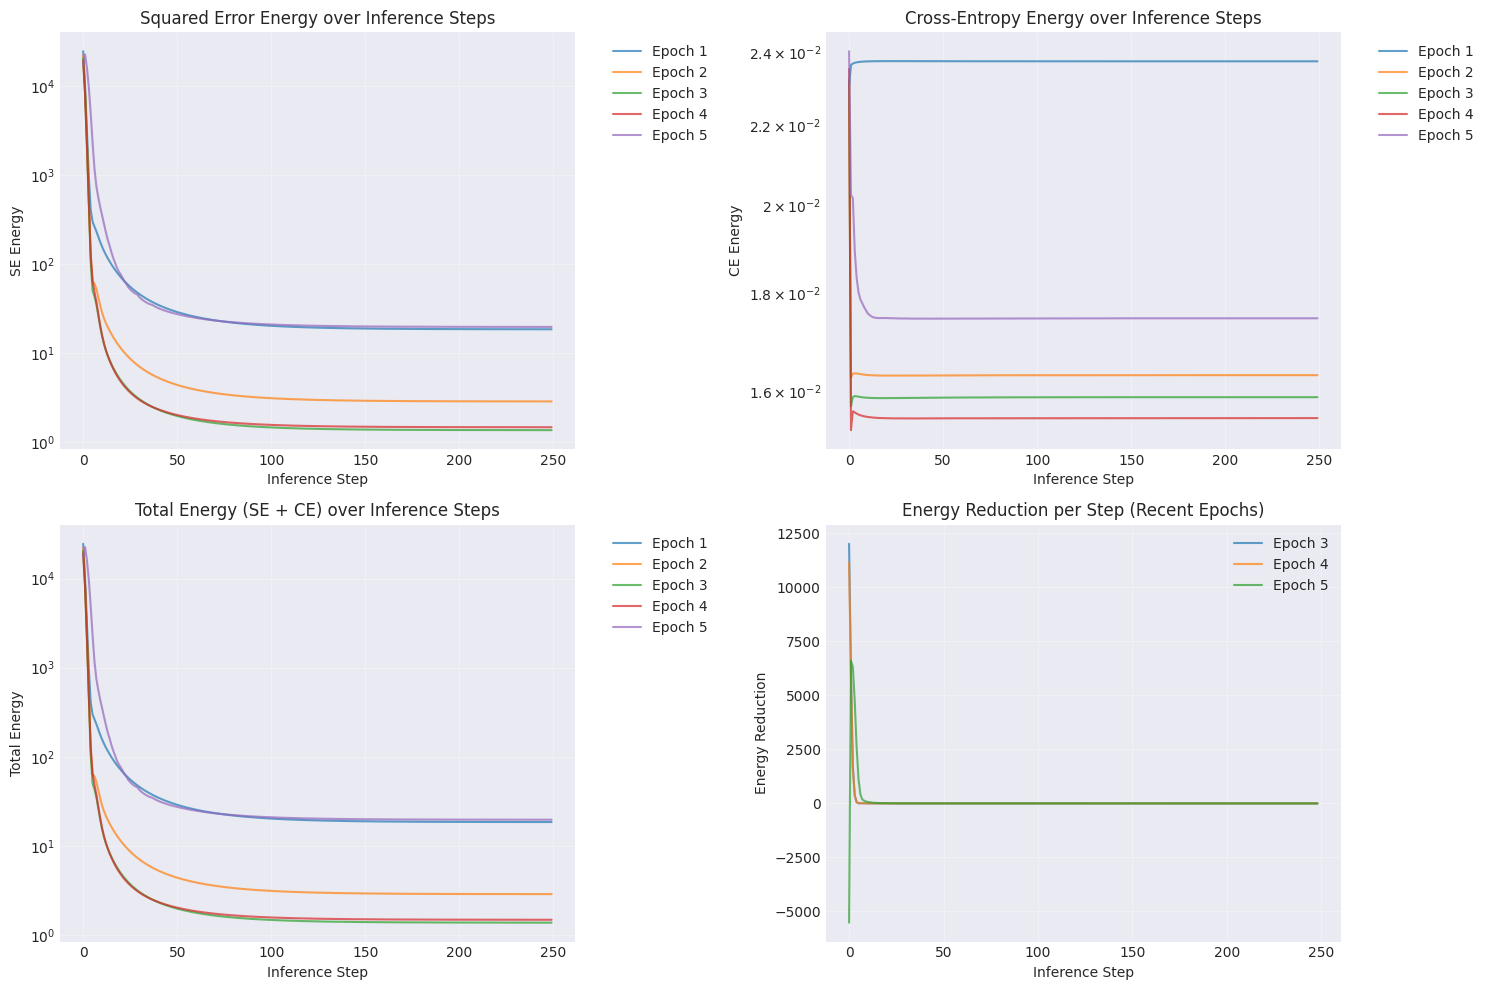

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot every 5th epoch to avoid clutter
epochs_to_plot = range(0, len(history['first_batch_metrics']), max(1, len(history['first_batch_metrics']) // 10))

# SE Energy
for i in epochs_to_plot:
    m = history['first_batch_metrics'][i]
    axes[0, 0].plot(m['energies_se'], alpha=0.7, label=f'Epoch {i+1}')
axes[0, 0].set_xlabel('Inference Step')
axes[0, 0].set_ylabel('SE Energy')
axes[0, 0].set_title('Squared Error Energy over Inference Steps')
axes[0, 0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0, 0].set_yscale('log')
axes[0, 0].grid(True, alpha=0.3)

# CE Energy
for i in epochs_to_plot:
    m = history['first_batch_metrics'][i]
    axes[0, 1].plot(m['energies_ce'], alpha=0.7, label=f'Epoch {i+1}')
axes[0, 1].set_xlabel('Inference Step')
axes[0, 1].set_ylabel('CE Energy')
axes[0, 1].set_title('Cross-Entropy Energy over Inference Steps')
axes[0, 1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0, 1].set_yscale('log')
axes[0, 1].grid(True, alpha=0.3)

# Total Energy
for i in epochs_to_plot:
    m = history['first_batch_metrics'][i]
    total_e = m['energies_se'] + m['energies_ce']
    axes[1, 0].plot(total_e, alpha=0.7, label=f'Epoch {i+1}')
axes[1, 0].set_xlabel('Inference Step')
axes[1, 0].set_ylabel('Total Energy')
axes[1, 0].set_title('Total Energy (SE + CE) over Inference Steps')
axes[1, 0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1, 0].set_yscale('log')
axes[1, 0].grid(True, alpha=0.3)

# Energy reduction per step (last 3 epochs)
for i in range(max(0, len(history['first_batch_metrics'])-3), len(history['first_batch_metrics'])):
    m = history['first_batch_metrics'][i]
    total_e = m['energies_se'] + m['energies_ce']
    reduction = -np.diff(total_e)
    axes[1, 1].plot(reduction, alpha=0.7, label=f'Epoch {i+1}')
axes[1, 1].set_xlabel('Inference Step')
axes[1, 1].set_ylabel('Energy Reduction')
axes[1, 1].set_title('Energy Reduction per Step (Recent Epochs)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Visualization 2: Training and Test Accuracy

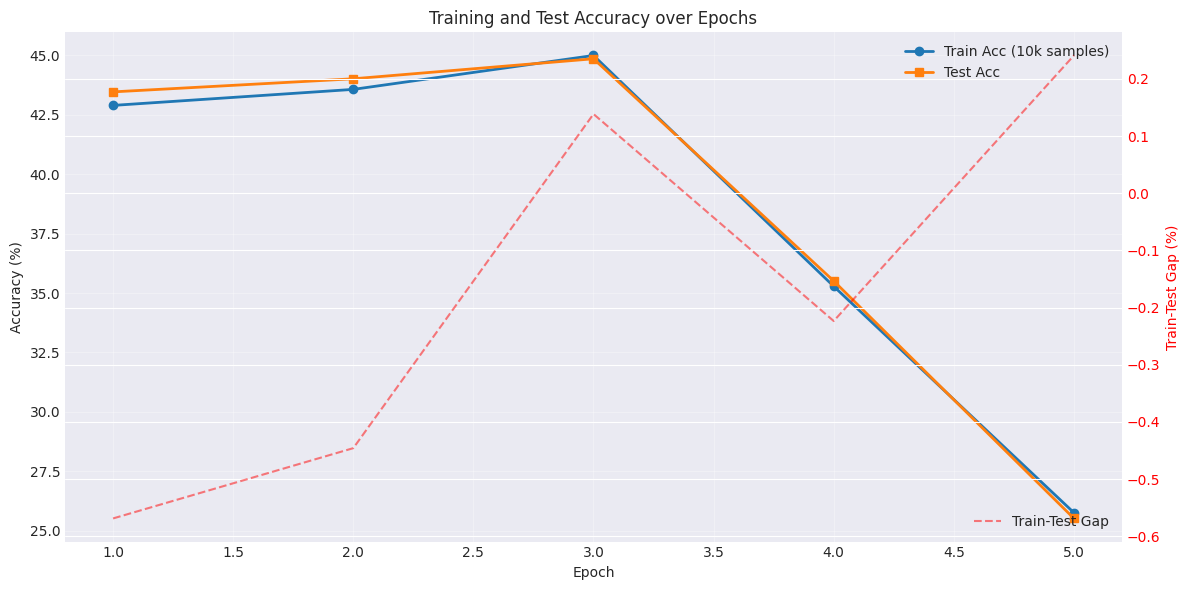

Final Train Accuracy: 25.76%
Final Test Accuracy: 25.52%
Final Train-Test Gap: 0.24%


In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

epochs = np.arange(1, len(history['train_acc']) + 1)
ax.plot(epochs, np.array(history['train_acc']) * 100, 'o-', label='Train Acc (10k samples)', linewidth=2)
ax.plot(epochs, np.array(history['test_acc']) * 100, 's-', label='Test Acc', linewidth=2)

ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Training and Test Accuracy over Epochs')
ax.legend()
ax.grid(True, alpha=0.3)

# Add gap indicator
gap = np.array(history['train_acc']) - np.array(history['test_acc'])
ax2 = ax.twinx()
ax2.plot(epochs, gap * 100, '--', color='red', alpha=0.5, label='Train-Test Gap')
ax2.set_ylabel('Train-Test Gap (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.legend(loc='lower right')

plt.tight_layout()
plt.show()

print(f"Final Train Accuracy: {history['train_acc'][-1]*100:.2f}%")
print(f"Final Test Accuracy: {history['test_acc'][-1]*100:.2f}%")
print(f"Final Train-Test Gap: {gap[-1]*100:.2f}%")

## Visualization 3: Fixed Point Residuals

**Iteration residuals**: $||z_t - z_{t-1}||$ measures convergence speed during inference.  
**Fixed point residual**: $||z_T - f(z_T, x)||$ measures how close we are to a true fixed point.

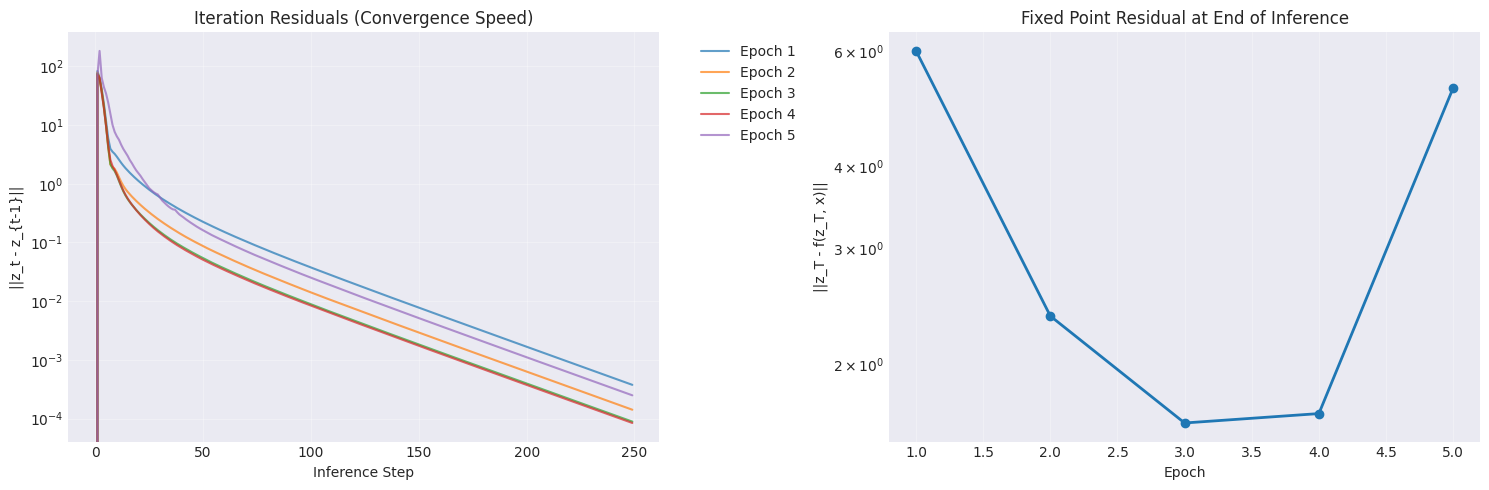


Final fixed point residual: 5.266175
This measures ||z_T - f(z_T, x)|| - ideally should be near zero for true equilibrium.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Iteration residuals
for i in epochs_to_plot:
    m = history['first_batch_metrics'][i]
    axes[0].plot(m['residuals'], alpha=0.7, label=f'Epoch {i+1}')
axes[0].set_xlabel('Inference Step')
axes[0].set_ylabel('||z_t - z_{t-1}||')
axes[0].set_title('Iteration Residuals (Convergence Speed)')
axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0].set_yscale('log')
axes[0].grid(True, alpha=0.3)

# Fixed point residual across epochs
fp_residuals = [m['final_fixed_point_residual'] for m in history['first_batch_metrics']]
axes[1].plot(range(1, len(fp_residuals)+1), fp_residuals, 'o-', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('||z_T - f(z_T, x)||')
axes[1].set_title('Fixed Point Residual at End of Inference')
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nFinal fixed point residual: {fp_residuals[-1]:.6f}")
print(f"This measures ||z_T - f(z_T, x)|| - ideally should be near zero for true equilibrium.")

## Visualization 4: Gradient Norms

Tracks both inference gradient norms (h-optimization) and weight gradient norms.

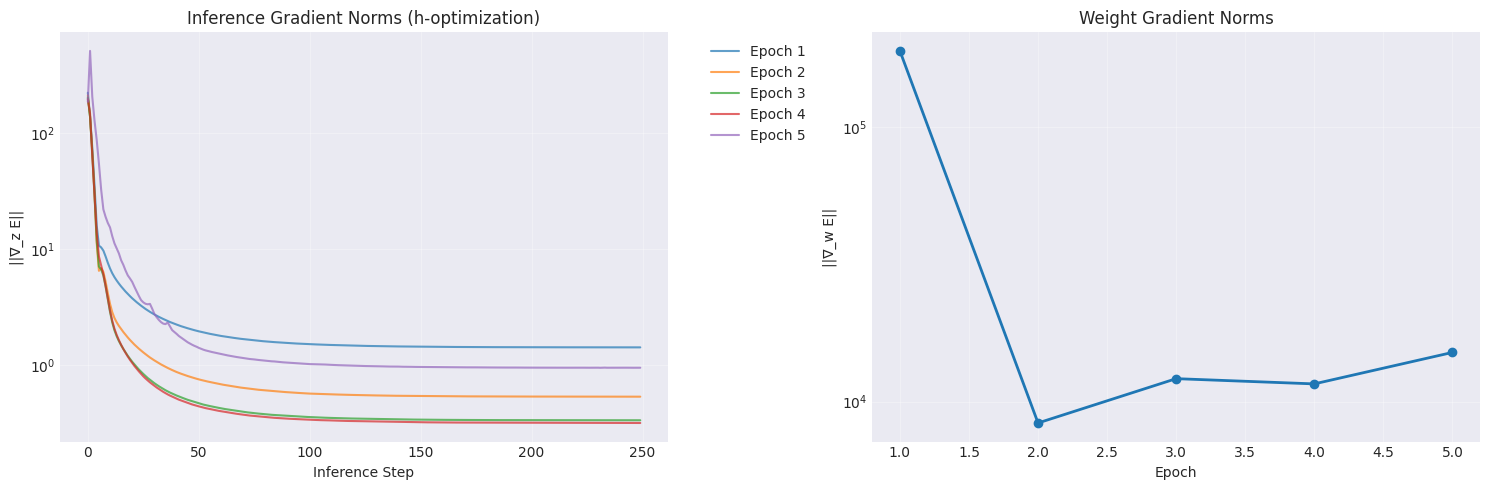

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Inference gradient norms
for i in epochs_to_plot:
    m = history['first_batch_metrics'][i]
    axes[0].plot(m['grad_norms'], alpha=0.7, label=f'Epoch {i+1}')
axes[0].set_xlabel('Inference Step')
axes[0].set_ylabel('||∇_z E||')
axes[0].set_title('Inference Gradient Norms (h-optimization)')
axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0].set_yscale('log')
axes[0].grid(True, alpha=0.3)

# Weight gradient norms across epochs
axes[1].plot(range(1, len(history['weight_grad_norms'])+1), history['weight_grad_norms'], 'o-', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('||∇_w E||')
axes[1].set_title('Weight Gradient Norms')
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Visualization 5: Hidden State Statistics

Tracks mean, std, min, max of z during inference to detect numerical issues.

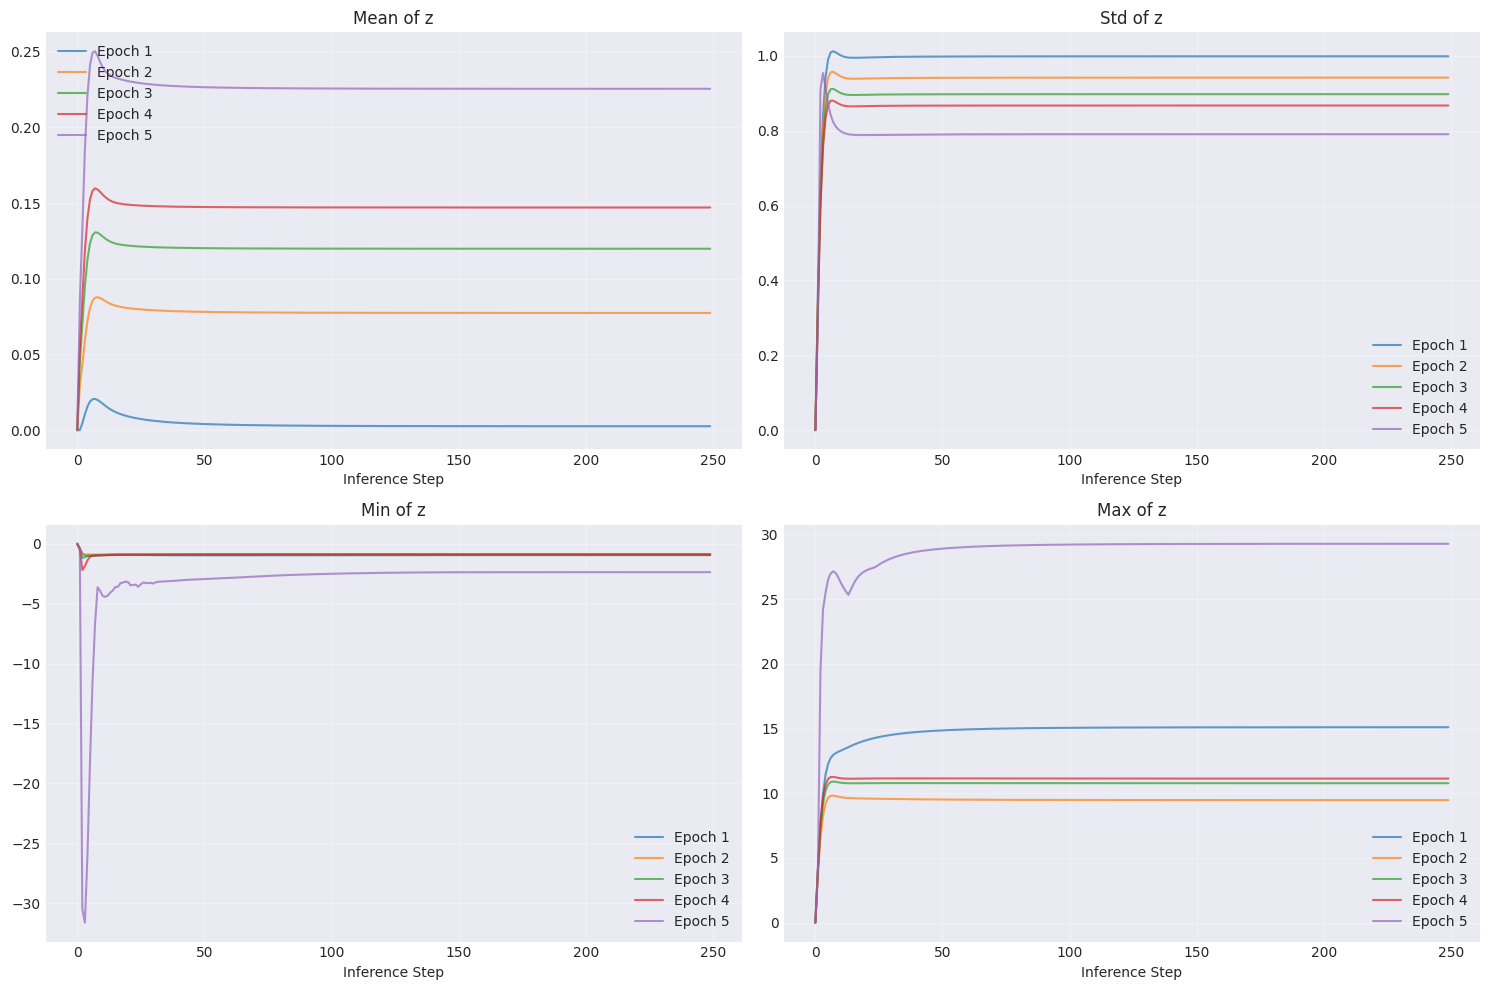

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Select recent epochs for detailed view
recent_epochs = range(max(0, len(history['first_batch_metrics'])-5), len(history['first_batch_metrics']))

for i in recent_epochs:
    m = history['first_batch_metrics'][i]
    stats = m['z_stats']
    
    means = [s['mean'] for s in stats]
    stds = [s['std'] for s in stats]
    mins = [s['min'] for s in stats]
    maxs = [s['max'] for s in stats]
    
    axes[0, 0].plot(means, alpha=0.7, label=f'Epoch {i+1}')
    axes[0, 1].plot(stds, alpha=0.7, label=f'Epoch {i+1}')
    axes[1, 0].plot(mins, alpha=0.7, label=f'Epoch {i+1}')
    axes[1, 1].plot(maxs, alpha=0.7, label=f'Epoch {i+1}')

axes[0, 0].set_title('Mean of z')
axes[0, 0].set_xlabel('Inference Step')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].set_title('Std of z')
axes[0, 1].set_xlabel('Inference Step')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].set_title('Min of z')
axes[1, 0].set_xlabel('Inference Step')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].set_title('Max of z')
axes[1, 1].set_xlabel('Inference Step')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Visualization 6: Energy Landscape Analysis

1D slice of energy landscape along gradient direction at final state.

In [ ]:
# Compute energy landscape slice for first sample of first batch
model.eval()

with pxu.step(model, clear_params=pxc.VodeParam.Cache):
    init_eval(first_batch_x[:1], model=model)

h_opt = optim_h.optax_opt_fn()
z_h, _ = run_inference_with_tracking(
    T_steps, model.vode_z.h.get(), model.x_inj_cache.get(), 
    model.vode_out.h.get(), h_opt, model
)

# Get converged state and gradient
z_final = z_h[0]  # First sample
x_inj_single = model.x_inj_cache.get()[0]
label_single = model.vode_out.h.get()[0]
nudging = model.nudging.get()

@jax.checkpoint
def energy_fn(z):
    u_z = model.f(z, x_inj_single)
    diff = z - u_z
    e_z = (0.5 * diff * diff).sum()
    
    z_out = model.pool(model.gn_out(z)).flatten()
    logits = model.linear(z_out)
    e_out = (nudging * (-(label_single * jax.nn.log_softmax(logits)))).sum()
    
    return e_z + e_out

grad_z = jax.grad(energy_fn)(z_final)
grad_norm = jnp.linalg.norm(grad_z.flatten())
grad_dir = grad_z / (grad_norm + 1e-10)

# Sweep along gradient direction
alphas = np.linspace(-0.5, 0.5, 50)
energies = []
for alpha in alphas:
    z_perturbed = z_final + alpha * grad_dir
    e = energy_fn(z_perturbed)
    energies.append(float(e))

plt.figure(figsize=(10, 6))
plt.plot(alphas, energies, 'o-', linewidth=2)
plt.axvline(x=0, color='red', linestyle='--', label='Converged z')
plt.xlabel('α (step along gradient direction)')
plt.ylabel('Energy')
plt.title('Energy Landscape Slice Along Gradient Direction')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nGradient norm at converged state: {grad_norm:.6f}")
print(f"Energy at converged state: {energies[len(alphas)//2]:.6f}")

IndexError: list index out of range

## Summary Statistics

In [ ]:
print("="*60)
print("TRAINING SUMMARY")
print("="*60)
print(f"\nHyperparameters:")
print(f"  T steps: {T_steps}")
print(f"  Nudging: {nudging}")
print(f"  LR (weights): {lr_w}")
print(f"  LR (inference): {lr_h}")
print(f"  Momentum (inference): {mom_h}")
print(f"  Weight decay: {wd_w}")
print(f"  Channels: {chan}")

print(f"\nFinal Performance:")
print(f"  Train Accuracy (10k): {history['train_acc'][-1]*100:.2f}%")
print(f"  Test Accuracy: {history['test_acc'][-1]*100:.2f}%")
print(f"  Train-Test Gap: {(history['train_acc'][-1] - history['test_acc'][-1])*100:.2f}%")

print(f"\nConvergence Metrics (Final Epoch):")
final_metrics = history['first_batch_metrics'][-1]
print(f"  Final SE Energy: {final_metrics['energies_se'][-1]:.6f}")
print(f"  Final CE Energy: {final_metrics['energies_ce'][-1]:.6f}")
print(f"  Final Total Energy: {final_metrics['energies_se'][-1] + final_metrics['energies_ce'][-1]:.6f}")
print(f"  Fixed Point Residual: {final_metrics['final_fixed_point_residual']:.6f}")
print(f"  Final Gradient Norm: {final_metrics['grad_norms'][-1]:.6f}")
print(f"  Final Iteration Residual: {final_metrics['residuals'][-1]:.6f}")

print(f"\nEnergy Reduction:")
initial_total = final_metrics['energies_se'][0] + final_metrics['energies_ce'][0]
final_total = final_metrics['energies_se'][-1] + final_metrics['energies_ce'][-1]
reduction = (initial_total - final_total) / initial_total * 100
print(f"  Initial Total Energy: {initial_total:.6f}")
print(f"  Final Total Energy: {final_total:.6f}")
print(f"  Reduction: {reduction:.2f}%")

print("\n" + "="*60)

## Diagnostic Questions

Based on the plots above, consider:

1. **Energy Convergence**: Does energy decrease monotonically? Are there plateaus?
2. **Fixed Point Quality**: Is the fixed point residual small enough? Should T be larger?
3. **Gradient Vanishing**: Do gradients vanish during inference? Check the log scale.
4. **Overfitting**: Is the train-test gap large? Is it growing?
5. **Weight Learning**: Are weight gradients stable? Too large/small?
6. **Hidden State Health**: Does z explode or vanish? Check min/max.
7. **Energy Landscape**: Is the landscape smooth? Multiple local minima?
8. **SE vs CE Balance**: Is one energy component dominating? Should nudging change?

**Potential Issues to Investigate**:
- If fixed point residual is large: increase T or adjust lr_h
- If energies plateau early: check if learning rate is too small
- If z values explode: reduce lr_h or add gradient clipping
- If train-test gap is large: add regularization or data augmentation
- If weight gradients vanish: check nudging parameter and architecture